In [1]:
from IPython.display import HTML, display
from IPython import get_ipython

def set_css():
    display(HTML('''
    <style>
        pre {
            white-space: pre-wrap;
        }
    </style>
    '''))

ip = get_ipython()
if ip is not None:
    ip.events.register('pre_run_cell', set_css)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
!python score_gpt.py \
    --model_path "/content/drive/MyDrive/sft_checkpoint_epoch_1.pth" \
    --questions_file "test_questions.jsonl" \
    --output_file "evaluation_results_$(date +'%Y%m%d_%H%M%S').csv" \
    --vocab_size 50262 \
    --context_length 1024 \
    --emb_dim 512 \
    --n_heads 8 \
    --n_layers 12 \
    --drop_rate 0.1 \
    --max_tokens 200 \
    --temperature 0.3 \
    --device "auto"

2025-11-17 12:14:09.790894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 12:14:09.808383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763381649.829413   19715 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763381649.835746   19715 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763381649.851987   19715 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Loaded evaluation results:
run
1    100
2    100
3    100
Name: question_id, dtype: int64

Per-run loose accuracy:
  Run 1: 17.00%
  Run 2: 20.00%
  Run 3: 21.00%

Majority-vote loose accuracy: 21.00%

Consistency across 3 runs (using loose_parsed_answer):
  n_questions: 100
  all_same: 67
  two_same_one_diff: 18
  all_diff: 2
  all_same_frac: 77.01%
  two_same_frac: 20.69%
  all_diff_frac: 2.30%

Accuracy by difficulty (loose):
Per run:
run                1         2         3
difficulty                              
easy        0.166667  0.166667  0.229167
hard        0.090909  0.090909  0.090909
medium      0.195122  0.268293  0.219512

Majority vote:
difficulty
easy      0.166667
hard      0.090909
medium    0.292683
Name: maj_correct, dtype: float64

Accuracy by topic (loose):
Per run:
run               1         2         3
topic                                  
ML         0.000000  0.000000  0.000000
art        0.000000  0.500000  0.500000
astronomy  0.200000  0.200000  0.20000

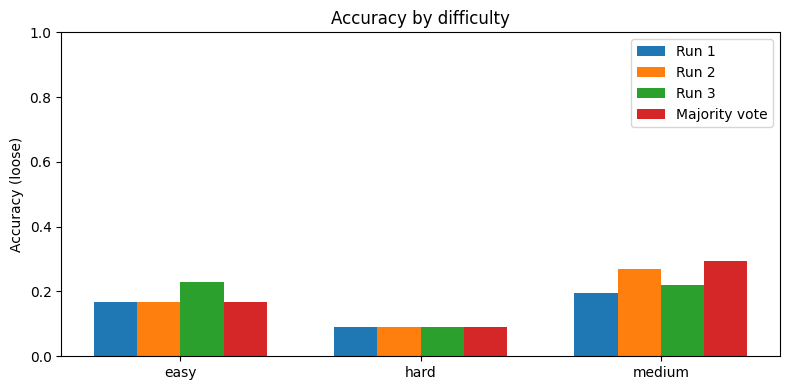

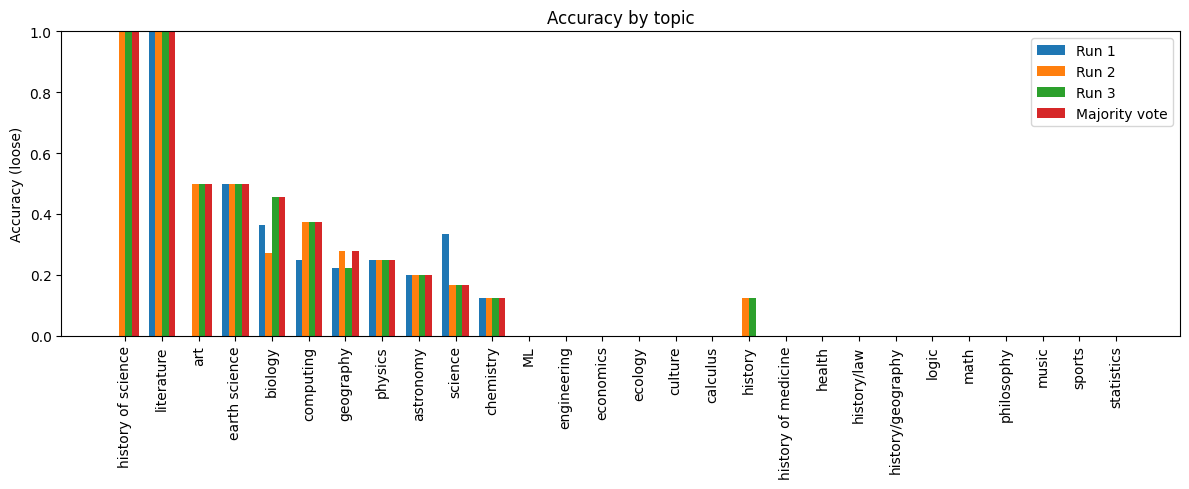

Run 1 loose accuracy: 17.00%
Run 2 loose accuracy: 20.00%
Run 3 loose accuracy: 21.00%
Majority-vote loose accuracy: 21.00%

Consistency:
All three runs same answer: 67 (77.01%)
Two same, one different:  18 (20.69%)
All different:            2 (2.30%)


In [11]:
#first 3 runs' analysis
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os

RESULT_FILES = [
    "evaluation_results_20251117_110504.csv",
    "evaluation_results_20251117_111226.csv",
    "evaluation_results_20251117_112128.csv",
]

TEST_QUESTIONS_PATH = "test_questions.jsonl"

dfs = []
for i, path in enumerate(RESULT_FILES, start=1):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing results file: {path}")
    df = pd.read_csv(path)
    df["run"] = i
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

print("Loaded evaluation results:")
print(all_df[["run", "question_id"]].groupby("run")["question_id"].nunique())



acc_by_run = all_df.groupby("run")["loose_correct"].mean().sort_index()
print("\nPer-run loose accuracy:")
for run, acc in acc_by_run.items():
    print(f"  Run {run}: {acc * 100:.2f}%")

base_df = dfs[0][
    ["question_id", "correct_answer", "topic", "difficulty"]
].drop_duplicates(subset="question_id")
base_df = base_df.set_index("question_id")

pred_wide = all_df.pivot(
    index="question_id",
    columns="run",
    values="loose_parsed_answer"
)

def majority_vote(row):
    answers = [a for a in row if isinstance(a, str) and a.strip() != ""]
    if not answers:
        return np.nan
    counts = Counter(answers)
    max_count = max(counts.values())
    top = [k for k, v in counts.items() if v == max_count]
    return sorted(top)[0]

maj_pred = pred_wide.apply(majority_vote, axis=1)

base_df["maj_pred"] = maj_pred
base_df["maj_correct"] = base_df["maj_pred"] == base_df["correct_answer"]

maj_acc = base_df["maj_correct"].mean()
print(f"\nMajority-vote loose accuracy: {maj_acc * 100:.2f}%")

def consistency_stats(pred_matrix: pd.DataFrame):
    all_same = 0
    two_same_one_diff = 0
    all_diff = 0

    for _, row in pred_matrix.iterrows():
        answers = [a for a in row if isinstance(a, str) and a.strip() != ""]
        if len(answers) < 2:
            continue
        uniq = list(set(answers))
        if len(uniq) == 1:
            all_same += 1
        elif len(uniq) == 2:
            two_same_one_diff += 1
        else:
            all_diff += 1

    total = all_same + two_same_one_diff + all_diff
    if total == 0:
        return {}

    return {
        "n_questions": pred_matrix.shape[0],
        "all_same": all_same,
        "two_same_one_diff": two_same_one_diff,
        "all_diff": all_diff,
        "all_same_frac": all_same / total,
        "two_same_frac": two_same_one_diff / total,
        "all_diff_frac": all_diff / total,
    }

cons = consistency_stats(pred_wide)
print("\nConsistency across 3 runs (using loose_parsed_answer):")
for k, v in cons.items():
    if "frac" in k:
        print(f"  {k}: {v * 100:.2f}%")
    else:
        print(f"  {k}: {v}")


maj_correct_per_q = base_df["maj_correct"]
all_df = all_df.merge(
    maj_correct_per_q.rename("maj_correct"),
    on="question_id",
    how="left"
)


diff_run = all_df.groupby(["difficulty", "run"])["loose_correct"].mean().unstack("run")
diff_maj = all_df.groupby("difficulty")["maj_correct"].mean()

print("\nAccuracy by difficulty (loose):")
print("Per run:")
print(diff_run)
print("\nMajority vote:")
print(diff_maj)

diff_plot = diff_run.copy()
diff_plot["maj_vote"] = diff_maj
diff_plot = diff_plot.reset_index()

topic_run = all_df.groupby(["topic", "run"])["loose_correct"].mean().unstack("run")
topic_maj = all_df.groupby("topic")["maj_correct"].mean()

print("\nAccuracy by topic (loose):")
print("Per run:")
print(topic_run.head())
print("\nMajority vote:")
print(topic_maj.head())

topic_plot = topic_run.copy()
topic_plot["maj_vote"] = topic_maj
topic_plot = topic_plot.reset_index()

topic_plot = topic_plot.sort_values("maj_vote", ascending=False).reset_index(drop=True)


os.makedirs("analysis_plots", exist_ok=True)

difficulties = diff_plot["difficulty"].tolist()
x = np.arange(len(difficulties))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 4))

for i, col in enumerate([1, 2, 3, "maj_vote"]):
    label = f"Run {col}" if isinstance(col, int) else "Majority vote"
    vals = diff_plot[col].values
    ax.bar(x + (i - 1.5) * width, vals, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(difficulties)
ax.set_ylabel("Accuracy (loose)")
ax.set_title("Accuracy by difficulty")
ax.set_ylim(0, 1.0)
ax.legend(loc="best")
plt.tight_layout()
plt.show()
plt.savefig("analysis_plots/accuracy_by_difficulty.png", dpi=200)
plt.close()

topics = topic_plot["topic"].tolist()
x = np.arange(len(topics))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))

for i, col in enumerate([1, 2, 3, "maj_vote"]):
    label = f"Run {col}" if isinstance(col, int) else "Majority vote"
    vals = topic_plot[col].values
    ax.bar(x + (i - 1.5) * width, vals, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(topics, rotation=90)
ax.set_ylabel("Accuracy (loose)")
ax.set_title("Accuracy by topic")
ax.set_ylim(0, 1.0)
ax.legend(loc="best")
plt.tight_layout()
plt.show()
plt.savefig("analysis_plots/accuracy_by_topic.png", dpi=200)
plt.close()

for run, acc in acc_by_run.items():
    print(f"Run {run} loose accuracy: {acc * 100:.2f}%")
print(f"Majority-vote loose accuracy: {maj_acc * 100:.2f}%")

print("\nConsistency:")
print(f"All three runs same answer: {cons['all_same']} "
      f"({cons['all_same_frac'] * 100:.2f}%)")
print(f"Two same, one different:  {cons['two_same_one_diff']} "
      f"({cons['two_same_frac'] * 100:.2f}%)")
print(f"All different:            {cons['all_diff']} "
      f"({cons['all_diff_frac'] * 100:.2f}%)")



Loaded evaluation results:
run
1    100
2    100
3    100
4    100
Name: question_id, dtype: int64

Per-run loose accuracy:
  Run 1: 17.00%
  Run 2: 20.00%
  Run 3: 21.00%
  Run 4: 14.00%

Majority-vote loose accuracy: 21.00%

Consistency across 3 runs (using loose_parsed_answer):
  n_questions: 100
  all_same: 41
  two_same_one_diff: 45
  all_diff: 8
  all_same_frac: 43.62%
  two_same_frac: 47.87%
  all_diff_frac: 8.51%

Accuracy by difficulty (loose):
Per run:
run                1         2         3         4
difficulty                                        
easy        0.166667  0.166667  0.229167  0.104167
hard        0.090909  0.090909  0.090909  0.181818
medium      0.195122  0.268293  0.219512  0.170732

Majority vote:
difficulty
easy      0.166667
hard      0.090909
medium    0.292683
Name: maj_correct, dtype: float64

Accuracy by topic (loose):
Per run:
run               1         2         3         4
topic                                            
ML         0.000000  0.

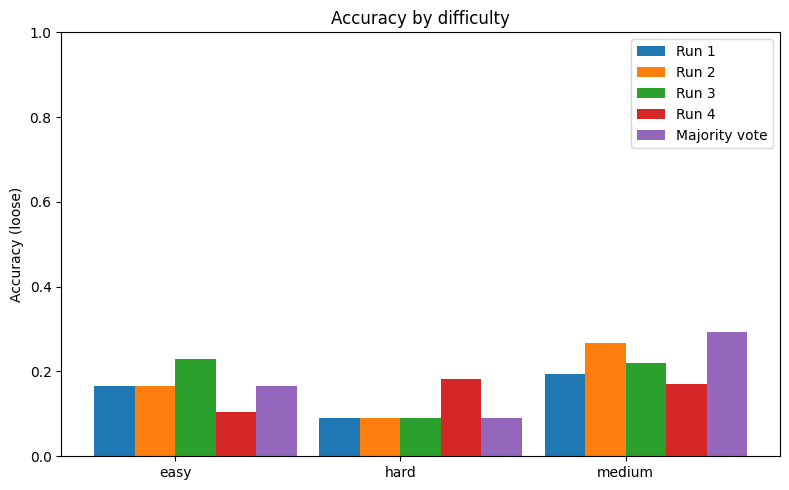

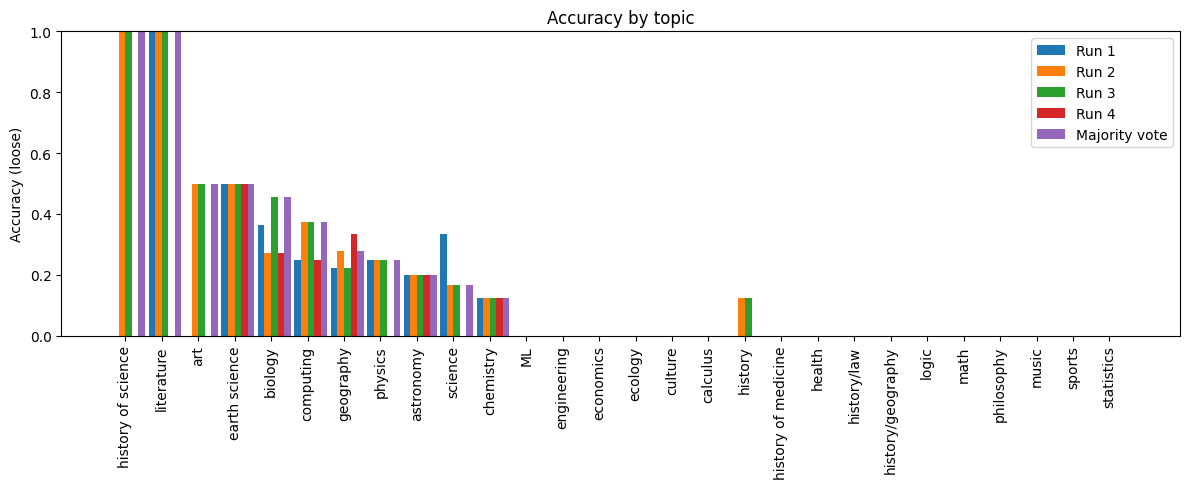

Run 1 loose accuracy: 17.00%
Run 2 loose accuracy: 20.00%
Run 3 loose accuracy: 21.00%
Run 4 loose accuracy: 14.00%
Majority-vote loose accuracy: 21.00%

Consistency:
All three runs same answer: 41 (43.62%)
Two same, one different:  45 (47.87%)
All different:            8 (8.51%)


In [15]:
#4th run (parser modified)
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os

RESULT_FILES = [
    "evaluation_results_20251117_110504.csv",
    "evaluation_results_20251117_111226.csv",
    "evaluation_results_20251117_112128.csv",
    "modified_parser_run.csv"
]

TEST_QUESTIONS_PATH = "test_questions.jsonl"

dfs = []
for i, path in enumerate(RESULT_FILES, start=1):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing results file: {path}")
    df = pd.read_csv(path)
    df["run"] = i
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

print("Loaded evaluation results:")
print(all_df[["run", "question_id"]].groupby("run")["question_id"].nunique())



acc_by_run = all_df.groupby("run")["loose_correct"].mean().sort_index()
print("\nPer-run loose accuracy:")
for run, acc in acc_by_run.items():
    print(f"  Run {run}: {acc * 100:.2f}%")

base_df = dfs[0][
    ["question_id", "correct_answer", "topic", "difficulty"]
].drop_duplicates(subset="question_id")
base_df = base_df.set_index("question_id")

pred_wide = all_df.pivot(
    index="question_id",
    columns="run",
    values="loose_parsed_answer"
)

def majority_vote(row):
    answers = [a for a in row if isinstance(a, str) and a.strip() != ""]
    if not answers:
        return np.nan
    counts = Counter(answers)
    max_count = max(counts.values())
    top = [k for k, v in counts.items() if v == max_count]
    return sorted(top)[0]

maj_pred = pred_wide.apply(majority_vote, axis=1)

base_df["maj_pred"] = maj_pred
base_df["maj_correct"] = base_df["maj_pred"] == base_df["correct_answer"]

maj_acc = base_df["maj_correct"].mean()
print(f"\nMajority-vote loose accuracy: {maj_acc * 100:.2f}%")

def consistency_stats(pred_matrix: pd.DataFrame):
    all_same = 0
    two_same_one_diff = 0
    all_diff = 0

    for _, row in pred_matrix.iterrows():
        answers = [a for a in row if isinstance(a, str) and a.strip() != ""]
        if len(answers) < 2:
            continue
        uniq = list(set(answers))
        if len(uniq) == 1:
            all_same += 1
        elif len(uniq) == 2:
            two_same_one_diff += 1
        else:
            all_diff += 1

    total = all_same + two_same_one_diff + all_diff
    if total == 0:
        return {}

    return {
        "n_questions": pred_matrix.shape[0],
        "all_same": all_same,
        "two_same_one_diff": two_same_one_diff,
        "all_diff": all_diff,
        "all_same_frac": all_same / total,
        "two_same_frac": two_same_one_diff / total,
        "all_diff_frac": all_diff / total,
    }

cons = consistency_stats(pred_wide)
print("\nConsistency across 3 runs (using loose_parsed_answer):")
for k, v in cons.items():
    if "frac" in k:
        print(f"  {k}: {v * 100:.2f}%")
    else:
        print(f"  {k}: {v}")


maj_correct_per_q = base_df["maj_correct"]
all_df = all_df.merge(
    maj_correct_per_q.rename("maj_correct"),
    on="question_id",
    how="left"
)


diff_run = all_df.groupby(["difficulty", "run"])["loose_correct"].mean().unstack("run")
diff_maj = all_df.groupby("difficulty")["maj_correct"].mean()

print("\nAccuracy by difficulty (loose):")
print("Per run:")
print(diff_run)
print("\nMajority vote:")
print(diff_maj)

diff_plot = diff_run.copy()
diff_plot["maj_vote"] = diff_maj
diff_plot = diff_plot.reset_index()

topic_run = all_df.groupby(["topic", "run"])["loose_correct"].mean().unstack("run")
topic_maj = all_df.groupby("topic")["maj_correct"].mean()

print("\nAccuracy by topic (loose):")
print("Per run:")
print(topic_run.head())
print("\nMajority vote:")
print(topic_maj.head())

topic_plot = topic_run.copy()
topic_plot["maj_vote"] = topic_maj
topic_plot = topic_plot.reset_index()

topic_plot = topic_plot.sort_values("maj_vote", ascending=False).reset_index(drop=True)


os.makedirs("analysis_plots", exist_ok=True)

difficulties = diff_plot["difficulty"].tolist()
x = np.arange(len(difficulties))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 5))

for i, col in enumerate([1, 2, 3, 4, "maj_vote"]):
    label = f"Run {col}" if isinstance(col, int) else "Majority vote"
    vals = diff_plot[col].values
    ax.bar(x + (i - 1.5) * width, vals, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(difficulties)
ax.set_ylabel("Accuracy (loose)")
ax.set_title("Accuracy by difficulty")
ax.set_ylim(0, 1.0)
ax.legend(loc="best")
plt.tight_layout()
plt.show()
plt.savefig("analysis_plots/accuracy_by_difficulty.png", dpi=200)
plt.close()

topics = topic_plot["topic"].tolist()
x = np.arange(len(topics))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))

for i, col in enumerate([1, 2, 3, 4, "maj_vote"]):
    label = f"Run {col}" if isinstance(col, int) else "Majority vote"
    vals = topic_plot[col].values
    ax.bar(x + (i - 1.5) * width, vals, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(topics, rotation=90)
ax.set_ylabel("Accuracy (loose)")
ax.set_title("Accuracy by topic")
ax.set_ylim(0, 1.0)
ax.legend(loc="best")
plt.tight_layout()
plt.show()
plt.savefig("analysis_plots/accuracy_by_topic.png", dpi=200)
plt.close()

for run, acc in acc_by_run.items():
    print(f"Run {run} loose accuracy: {acc * 100:.2f}%")
print(f"Majority-vote loose accuracy: {maj_acc * 100:.2f}%")

print("\nConsistency:")
print(f"All three runs same answer: {cons['all_same']} "
      f"({cons['all_same_frac'] * 100:.2f}%)")
print(f"Two same, one different:  {cons['two_same_one_diff']} "
      f"({cons['two_same_frac'] * 100:.2f}%)")
print(f"All different:            {cons['all_diff']} "
      f"({cons['all_diff_frac'] * 100:.2f}%)")

